In [1]:
import polars as pl
import torch
import umap
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Lasso
import numpy as np
import seaborn as sns

from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from explanation import *
from visualization import *


%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 1) & (pl.col('hour') < 6)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_week_cos', 'day_of_month_cos', 'minute_cos', 'day_of_week_sin', 'day_of_month_sin', 'minute_sin']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_week_cos', 'day_of_month_cos', 'minute_cos', 'day_of_week_sin', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 116)
(2765755, 116)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

95516


In [5]:
model = CombinedModel(input_dim=X_train.shape[1], hidden_layers=[64, 64], latent_dim=16, num_classes=2)
model.load_state_dict(torch.load("model_combined_bin.pth"))
print(model)

CombinedModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=116, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=116, bias=True)
    )
  )
  (classifier): Classifier(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


In [6]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_train, z_train = model(X_train_tensor)
    y_pred_train = torch.argmax(y_pred_train, dim=1)
y_pred_train = y_pred_train.cpu().detach().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)

(24451934,)
(24451934, 16)


In [7]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_test, z_test = model(X_test_tensor)
    y_pred_test = torch.argmax(y_pred_test, dim=1)
y_pred_test = y_pred_test.cpu().detach().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)

(2765755,)
(2765755, 16)


In [8]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00  24384055
           1       0.29      0.95      0.44     67879

    accuracy                           0.99  24451934
   macro avg       0.64      0.97      0.72  24451934
weighted avg       1.00      0.99      1.00  24451934



In [9]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2759074
           1       0.63      0.94      0.75      6681

    accuracy                           1.00   2765755
   macro avg       0.81      0.97      0.88   2765755
weighted avg       1.00      1.00      1.00   2765755



In [12]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=10000, anomaly_ratio=0.3)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]

[6681]


In [65]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(10000, 2)

In [15]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]

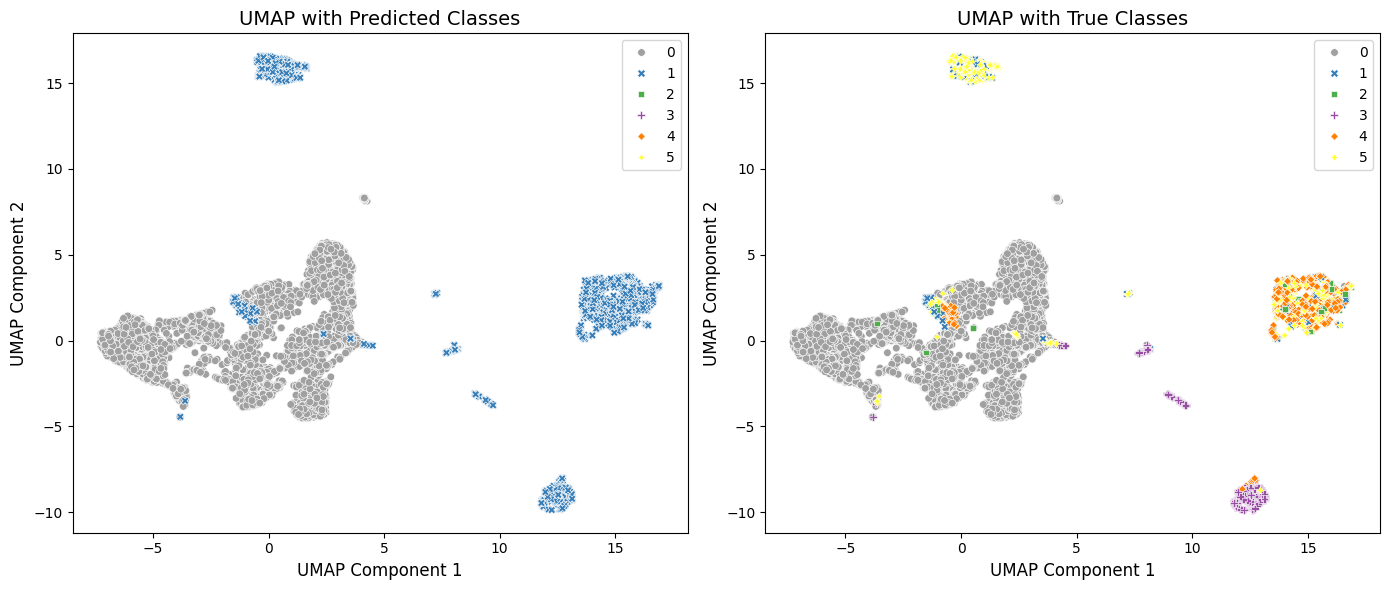

In [67]:
plot_comparison_all(embedding, y_pred_sampled, y_test_anomalies_sampled, 
                custom_palette, all_labels, "UMAP", save_path="figs/combined_model_bin_pred_classes_umap.png")

In [27]:
z_test_a = z_test[y_pred_test != 0]
y_test_a = y_test[y_pred_test != 0]
y_pred_test_a = y_pred_test[y_pred_test != 0]
y_pred_test_anomalies_a = y_test_anomalies[y_pred_test != 0]

#embedding = reducer.fit_transform(z_test_a)
#embedding.shape

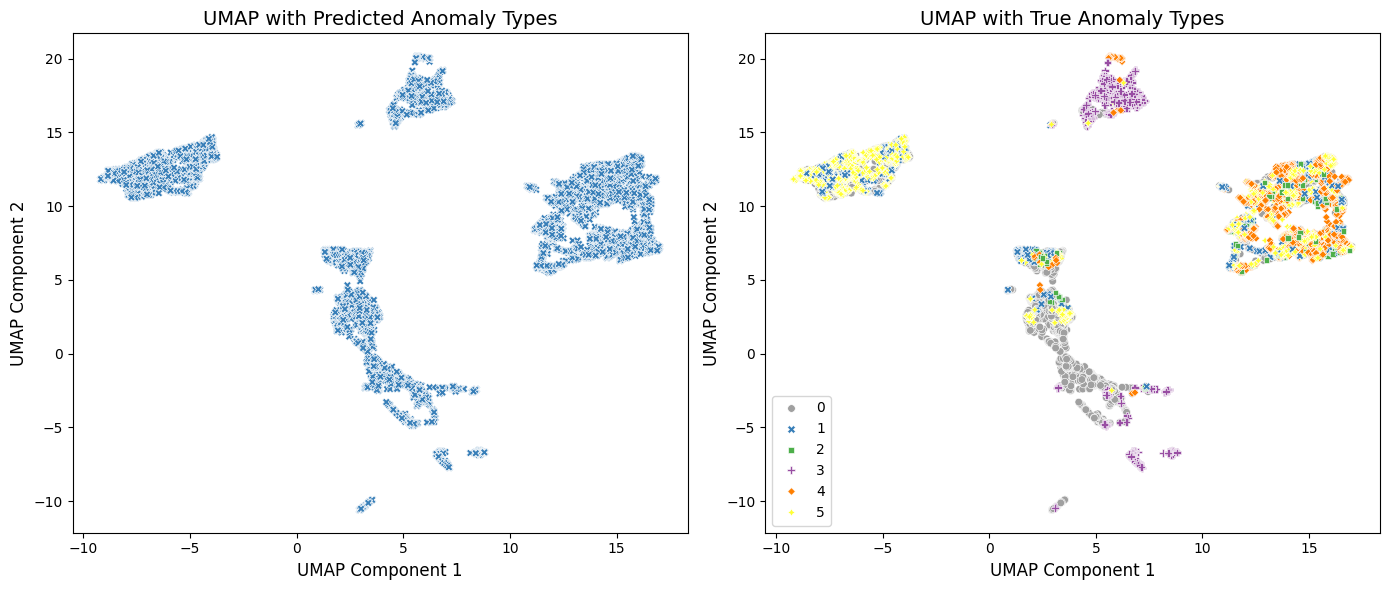

In [72]:
plot_comparison_anomalies(embedding, y_pred_test_a, y_pred_test_anomalies_a, custom_palette, all_labels, "UMAP", "figs/combined_model_predictions_anomalies_umap.png")

In [20]:
z_train_sampled, y_train_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.3)

[67879]


In [21]:
reducer = umap.UMAP()
reducer.fit(z_train_sampled)
reducer.embedding_.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)

In [22]:
test_embedding = reducer.transform(z_sampled)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


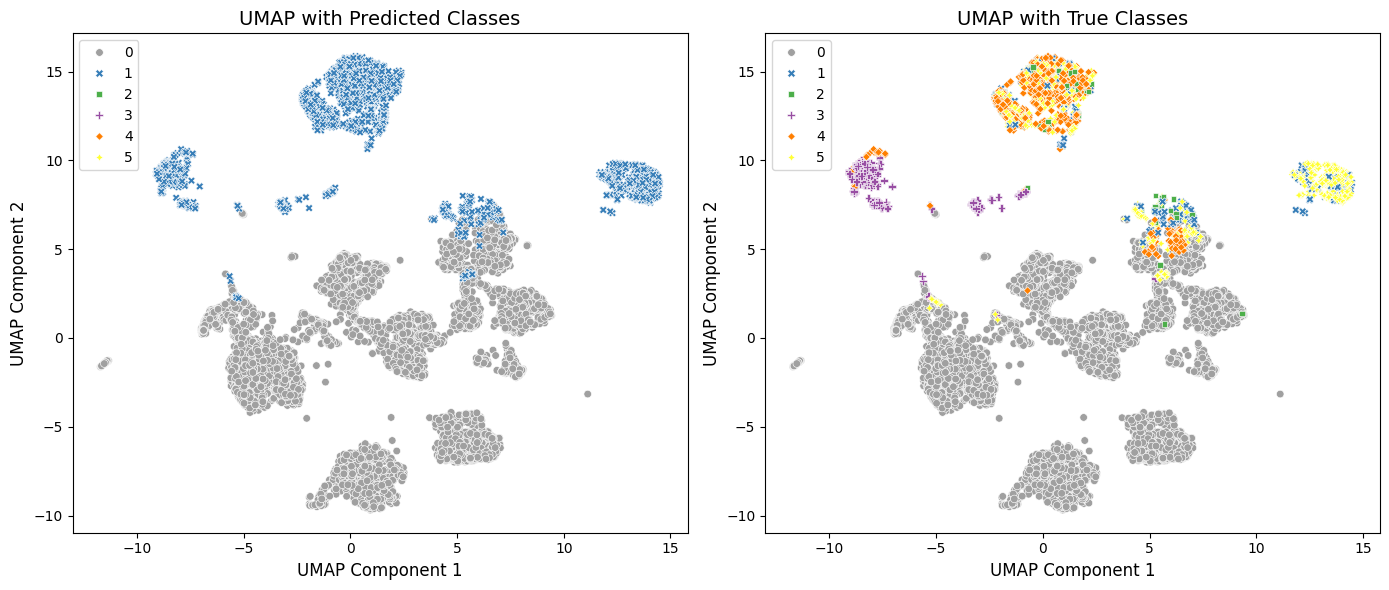

In [23]:
plot_comparison_all(test_embedding, y_pred_sampled, y_test_anomalies_sampled, 
                custom_palette, all_labels, "UMAP", save_path="figs/combined_model_bin_pred_classes_umap.png")

In [28]:
test_embedding = reducer.fit_transform(z_test_a)
test_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(9955, 2)

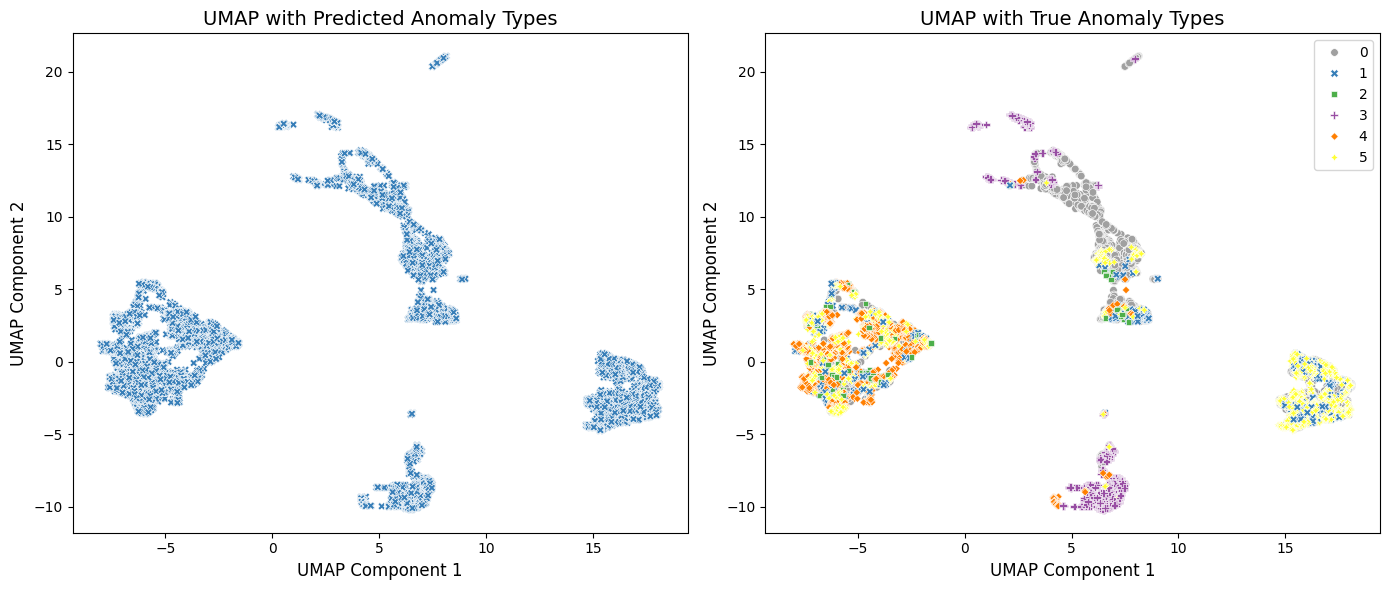

In [29]:
plot_comparison_anomalies(test_embedding, y_pred_test_a, y_pred_test_anomalies_a, custom_palette, all_labels, "UMAP", "figs/combined_model_predictions_anomalies_umap.png")